# Chest X-Ray Classification

### Objective

This project aims to develop and compare two deep learning models for the classification of chest X-ray images into four categories:

- COVID
- Normal
- Lung Opacity
- Viral Pneumonia



### 🪟 Libraries and Dependencies :

In [ ]:
!pip -q install kagglehub
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import imagehash
from collections import defaultdict
import hashlib
import random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from PIL import Image
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNet
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import seaborn as sns


## Dataset Acquisition

The COVID-19 Radiography Database is obtained directly from Kaggle using KaggleHub to ensure reproducibility.

In [5]:
path = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

print("Dataset path:")
print(path)

100%|██████████| 778M/778M [00:07<00:00, 110MB/s]

Extracting files...


Dataset path:
/root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5


#  Dataset Exploration
Inspect the dataset structure and identify the available classes and files before any preprocessing or model development.

In [6]:
root = path

print("Contents of dataset:\n")

for item in sorted(os.listdir(root)):
    print(item)

Contents of dataset:

COVID-19_Radiography_Dataset


In [7]:
dataset_root = os.path.join(
    path,
    "COVID-19_Radiography_Dataset"
)

print("Dataset root:\n")
print(dataset_root)

print("\nContents:\n")

for item in sorted(os.listdir(dataset_root)):
    print(item)

Dataset root:

/root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset

Contents:

COVID
COVID.metadata.xlsx
Lung_Opacity
Lung_Opacity.metadata.xlsx
Normal
Normal.metadata.xlsx
README.md.txt
Viral Pneumonia
Viral Pneumonia.metadata.xlsx


Before counting images, I want to know: what files are included, i need images nothing else, other files (that I do not use in my proj) may contain information that lead to dataleakage

In [8]:
covid_folder = os.path.join(
    dataset_root,
    "COVID"
)

print("COVID folder contents:\n")

for item in sorted(os.listdir(covid_folder)):
    print(item)

COVID folder contents:

images
masks


counting images per class to check if the dataset is imbalance

In [9]:
classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

for cls in classes:

    image_dir = os.path.join(
        dataset_root,
        cls,
        "images"
    )

    count = len(os.listdir(image_dir))

    print(f"{cls}: {count} images")

COVID: 3616 images
Normal: 10192 images
Lung_Opacity: 6012 images
Viral Pneumonia: 1345 images


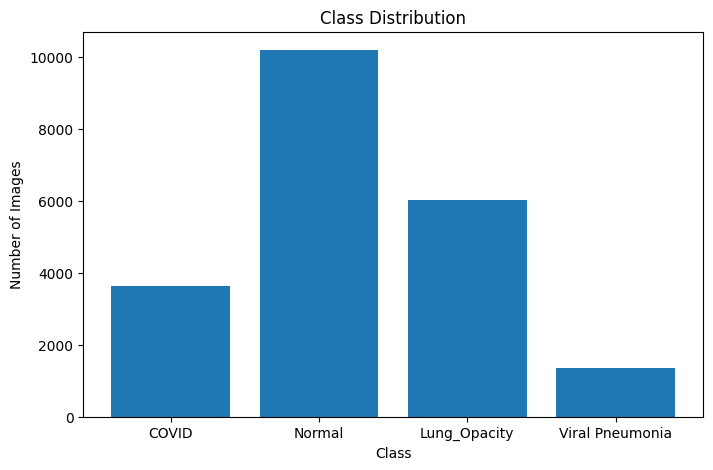

In [10]:

class_counts = {
    "COVID": 3616,
    "Normal": 10192,
    "Lung_Opacity": 6012,
    "Viral Pneumonia": 1345
}

plt.figure(figsize=(8,5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

⛔Observation:

 The dataset is ***imbalanced***. The Normal class contains the largest number of images, while Viral Pneumonia contains the smallest number.

✅ This motivates the use of stratified splitting and evaluation metrics beyond simple accuracy, such as precision, recall, F1-score, and ROC-AUC.



---



---



## Data Quality and Leakage Assessment

Before splitting the dataset, potential sources of data leakage must be investigated. Metadata files are inspected to identify patient identifiers, duplicated records, and other information that could compromise the validity of model evaluation.

In [11]:
covid_metadata = pd.read_excel(
    os.path.join(
        dataset_root,
        "COVID.metadata.xlsx"
    )
)

covid_metadata.head()

,FILE NAME,FORMAT,SIZE,URL
0,COVID-1,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
1,COVID-2,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
2,COVID-3,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
3,COVID-4,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
4,COVID-5,PNG,256*256,https://sirm.org/category/senza-categoria/covi...


#### ***Metadata Inspection***

Metadata files were inspected before model development to identify potential sources of data leakage.
The metadata contains image identifiers, image format, image size, and source URLs. No obvious patient identifiers or clinical outcome variables were observed.
Only image pixels are used for model training. Metadata fields such as URLs are excluded to avoid introducing illegitimate features and potential data leakage.

### Duplicate Image Assessment

Duplicate images can introduce data leakage if identical samples appear in both training and test sets.

To assess this risk, image hashes are computed and compared across the dataset.

In [12]:
!pip -q install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.6 MB/s eta 0:00:00


In [14]:
classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

hash_dict = defaultdict(list)

for cls in classes:

    image_dir = os.path.join(
        dataset_root,
        cls,
        "images"
    )

    files = os.listdir(image_dir)

    for file in files:

        try:

            img_path = os.path.join(image_dir, file)

            img = Image.open(img_path)

            h = str(imagehash.average_hash(img))

            hash_dict[h].append(
                (cls, file)
            )

        except:
            pass

duplicates = {
    h: files
    for h, files in hash_dict.items()
    if len(files) > 1
}

print("Number of duplicate hashes:", len(duplicates))

Number of duplicate hashes: 451


In [15]:
hashes = defaultdict(list)

for cls in classes:

    image_dir = os.path.join(dataset_root, cls, "images")

    for file in os.listdir(image_dir):

        filepath = os.path.join(image_dir, file)

        with open(filepath, "rb") as f:
            filehash = hashlib.md5(f.read()).hexdigest()

        hashes[filehash].append((cls, file))

exact_duplicates = {
    h: files
    for h, files in hashes.items()
    if len(files) > 1
}

print("Exact duplicate groups:", len(exact_duplicates))

Exact duplicate groups: 42


In [16]:
for h, files in list(exact_duplicates.items())[:5]:
    print("\nDuplicate group:")

    for cls, file in files:
        print(cls, "->", file)


Duplicate group:
COVID -> COVID-3207.png
COVID -> COVID-3208.png

Duplicate group:
COVID -> COVID-3573.png
COVID -> COVID-3574.png

Duplicate group:
COVID -> COVID-2718.png
COVID -> COVID-2715.png
COVID -> COVID-2719.png
COVID -> COVID-2717.png
COVID -> COVID-2716.png

Duplicate group:
COVID -> COVID-2823.png
COVID -> COVID-2822.png

Duplicate group:
COVID -> COVID-2942.png
COVID -> COVID-2941.png


In [18]:
cross_class_duplicates = []

for h, files in exact_duplicates.items():

    classes_in_group = set(
        cls for cls, file in files
    )

    if len(classes_in_group) > 1:
        cross_class_duplicates.append(files)

print(
    "Cross-class duplicate groups:",
    len(cross_class_duplicates)
)

Cross-class duplicate groups: 0


In [19]:
duplicate_images = 0

for h, files in exact_duplicates.items():
    duplicate_images += len(files) - 1

print("Duplicate images to remove:", duplicate_images)

clean_size = 21165 - duplicate_images

print("Clean dataset size:", clean_size)

Duplicate images to remove: 54
Clean dataset size: 21111


In [20]:
classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

seen_hashes = set()

records = []

for cls in classes:

    image_dir = os.path.join(
        dataset_root,
        cls,
        "images"
    )

    for file in os.listdir(image_dir):

        filepath = os.path.join(
            image_dir,
            file
        )

        with open(filepath, "rb") as f:
            md5 = hashlib.md5(
                f.read()
            ).hexdigest()

        if md5 not in seen_hashes:

            seen_hashes.add(md5)

            records.append({
                "filepath": filepath,
                "label": cls
            })

clean_df = pd.DataFrame(records)

print("Unique images:", len(clean_df))

Unique images: 21111


In [21]:
clean_df["label"].value_counts()

,count
label,
Normal,10191
Lung_Opacity,6012
COVID,3570
Viral Pneumonia,1338



###✅ Observation:  Duplicate Removal

Exact duplicate images were identified using MD5 hashing.

To avoid potential leakage, duplicate entries were removed before dataset splitting.

The cleaned dataset is represented by a dataframe containing unique image paths and labels.



---



---



## Reproducibility

To ensure reproducibility, random seeds are fixed and all experiments are performed using a consistent software environment.

In [22]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed fixed:", SEED)

Seed fixed: 42


## Train-Test Split

A stratified ( preserves the original class distribution across splits) hold-out test set is created before model development.

The test set remains untouched until the final evaluation stage.



In [23]:
train_df, test_df = train_test_split(
    clean_df,
    test_size=0.20,
    stratify=clean_df["label"],
    random_state=SEED
)

Training pool: 16888
Test set: 4223


In [24]:
print("Training distribution:\n")
print(train_df["label"].value_counts(normalize=True))

print("\nTest distribution:\n")
print(test_df["label"].value_counts(normalize=True))

Training distribution:

label
Normal             0.482769
Lung_Opacity       0.284758
COVID              0.169114
Viral Pneumonia    0.063359
Name: proportion, dtype: float64

Test distribution:

label
Normal             0.482595
Lung_Opacity       0.284869
COVID              0.169074
Viral Pneumonia    0.063462
Name: proportion, dtype: float64


In [25]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print(skf)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [26]:
for fold, (train_idx, val_idx) in enumerate(
    skf.split(train_df, train_df["label"]),
    start=1
):
    print(
        f"Fold {fold}: "
        f"Train={len(train_idx)}, "
        f"Validation={len(val_idx)}"
    )

Fold 1: Train=13510, Validation=3378
Fold 2: Train=13510, Validation=3378
Fold 3: Train=13510, Validation=3378
Fold 4: Train=13511, Validation=3377
Fold 5: Train=13511, Validation=3377




---



In [27]:
clean_df.head()

,filepath,label
0,/root/.cache/kagglehub/datasets/tawsifurrahman...,COVID
1,/root/.cache/kagglehub/datasets/tawsifurrahman...,COVID
2,/root/.cache/kagglehub/datasets/tawsifurrahman...,COVID
3,/root/.cache/kagglehub/datasets/tawsifurrahman...,COVID
4,/root/.cache/kagglehub/datasets/tawsifurrahman...,COVID


## Label Encoding

Machine learning models cannot directly process textual class labels. Therefore, the four diagnostic categories were converted into numerical labels using a Label Encoder.

The encoding used in this project is:

| Class | Encoded Label |
|---------|---------|
| COVID | 0 |
| Lung Opacity | 1 |
| Normal | 2 |
| Viral Pneumonia | 3 |

A new column (`label_encoded`) was added to the dataset dataframe. This encoded representation will be used during model training, validation, and evaluation.

The dataset dataframe now contains:

- `filepath`: location of the image file
- `label`: original class name
- `label_encoded`: numerical representation of the class

This preprocessing step ensures compatibility with TensorFlow and other machine learning libraries while preserving the mapping between original medical diagnoses and model outputs.

In [28]:
label_encoder = LabelEncoder()

clean_df["label_encoded"] = label_encoder.fit_transform(
    clean_df["label"]
)

print(label_encoder.classes_)

['COVID' 'Lung_Opacity' 'Normal' 'Viral Pneumonia']


In [29]:
train_df, test_df = train_test_split(
    clean_df,
    test_size=0.20,
    stratify=clean_df["label"],
    random_state=SEED
)

In [30]:
train_df.head()

,filepath,label,label_encoded
11305,/root/.cache/kagglehub/datasets/tawsifurrahman...,Normal,2
17991,/root/.cache/kagglehub/datasets/tawsifurrahman...,Lung_Opacity,1
1524,/root/.cache/kagglehub/datasets/tawsifurrahman...,COVID,0
793,/root/.cache/kagglehub/datasets/tawsifurrahman...,COVID,0
4921,/root/.cache/kagglehub/datasets/tawsifurrahman...,Normal,2


## Image Inspection

A sample chest X-ray image was visualized to verify that image loading was functioning correctly.

Observations:

- The image corresponds to a COVID-19 case.
- The original image resolution is 299 × 299 pixels.
- The image is a chest radiograph (X-ray) and appears in grayscale.
- Image quality is sufficient for deep learning classification.

Although the original images have a resolution of 299 × 299 pixels, all images will be resized to 224 × 224 pixels during preprocessing to match the input requirements of MobileNet and to reduce computational cost.

This inspection step serves as a sanity check before building the deep learning pipeline.

Label: COVID
Image size: (299, 299)


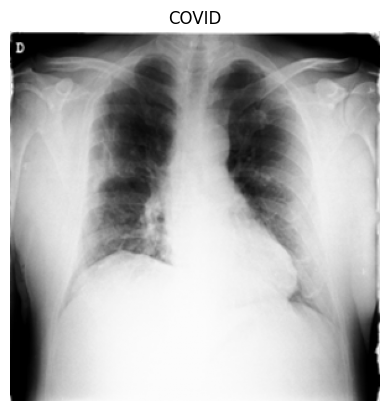

In [31]:
sample_path = clean_df.iloc[0]["filepath"]
sample_label = clean_df.iloc[0]["label"]

img = Image.open(sample_path)

print("Label:", sample_label)
print("Image size:", img.size)

plt.imshow(img, cmap="gray")
plt.title(sample_label)
plt.axis("off")
plt.show()

In [32]:
img = Image.open(sample_path)

img_array = np.array(img)

print("Shape:", img_array.shape)

Shape: (299, 299)


⏰ the dataset contains true grayscale images, not RGB images.

## TensorFlow Dataset Creation

After completing data cleaning, duplicate removal, train/test splitting, and label encoding, the next step is to create TensorFlow datasets for model training.

The dataset pipeline performs the following operations:

1. Load images from disk using their file paths.
2. Resize all images to 224 × 224 pixels.
3. Convert grayscale images to three channels for compatibility with MobileNet.
4. Normalize pixel values to the range [0,1].
5. Batch images for efficient training.
6. Prefetch data to improve training performance.

Using TensorFlow datasets improves computational efficiency and ensures a reproducible preprocessing workflow.

In [33]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [34]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = image / 255.0

    return image, label

In [35]:
sample_path = train_df.iloc[0]["filepath"]
sample_label = train_df.iloc[0]["label_encoded"]

image, label = load_image(sample_path, sample_label)

print("Image shape:", image.shape)
print("Label:", label)
print("Min pixel value:", tf.reduce_min(image).numpy())
print("Max pixel value:", tf.reduce_max(image).numpy())

Image shape: (224, 224, 3)
Label: 2
Min pixel value: 0.0
Max pixel value: 0.9815603


In [36]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [38]:
print(clean_df.shape)
print(train_df.shape)
print(test_df.shape)

(21111, 3)
(16888, 3)
(4223, 3)


## Data Augmentation

Deep learning models may overfit when trained on a limited set of medical images.

To improve generalization, data augmentation is applied during training. Random transformations generate slightly different versions of existing images while preserving their clinical meaning.

The following augmentation techniques are used:

- Random horizontal flip
- Small random rotations
- Random zoom

Data augmentation is applied only to training images and never to validation or test images.

In [39]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.05)
])

## Convolutional Neural Network (CNN)

A custom Convolutional Neural Network (CNN) is used as the baseline deep learning model.

The architecture consists of:

- Convolutional layers for feature extraction
- Max-pooling layers for spatial downsampling
- Dense layers for classification
- Dropout regularization to reduce overfitting

The final output layer contains four neurons corresponding to the four diagnostic classes:

- COVID
- Lung Opacity
- Normal
- Viral Pneumonia

This model serves as a baseline against which the pretrained MobileNet model will be compared.

In [44]:
def create_cnn_model():

    model = Sequential([

        Input(shape=(224, 224, 3)),

        data_augmentation,

        Conv2D(
            32,
            (3,3),
            activation="relu"
        ),

        MaxPooling2D((2,2)),

        Conv2D(
            64,
            (3,3),
            activation="relu"
        ),

        MaxPooling2D((2,2)),

        Conv2D(
            128,
            (3,3),
            activation="relu"
        ),

        MaxPooling2D((2,2)),

        GlobalAveragePooling2D(),

        Dense(
            128,
            activation="relu"
        ),

        Dropout(0.5),

        Dense(
            4,
            activation="softmax"
        )

    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [45]:
cnn_model = create_cnn_model()

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

### CNN Refinement

An initial CNN architecture based on a Flatten layer resulted in more than 11 million trainable parameters.

To improve computational efficiency and reduce overfitting, the Flatten layer was replaced with a Global Average Pooling layer.

This modification reduced the model size to approximately 110 thousand trainable parameters while preserving the network's ability to learn discriminative image features.

The resulting architecture is more suitable for cross-validation experiments and medical image classification tasks.

## CNN Training - Fold 1

The CNN model is initially trained on the first fold of the Stratified 5-Fold Cross Validation scheme.

Training is performed using:

- Adam optimizer
- Sparse categorical cross-entropy loss
- Accuracy metric
- Early stopping to prevent overfitting
- 5 training epochs maximum

The purpose of this first run is to verify that the training pipeline functions correctly and to estimate training time before executing all cross-validation folds.

In [46]:
# Cross-validation object
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# Get first fold only
train_idx, val_idx = next(
    skf.split(
        train_df["filepath"],
        train_df["label_encoded"]
    )
)

train_fold_df = train_df.iloc[train_idx]
val_fold_df = train_df.iloc[val_idx]

print("Training samples:", len(train_fold_df))
print("Validation samples:", len(val_fold_df))

Training samples: 13510
Validation samples: 3378


In [47]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_fold_df["filepath"].values,
        train_fold_df["label_encoded"].values
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_fold_df["filepath"].values,
        val_fold_df["label_encoded"].values
    )
)

train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [48]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

Train CNN  for 1 fold to validate the process and observe it

In [49]:
cnn_model = create_cnn_model()

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
423/423 ━━━━━━━━━━━━━━━━━━━━ 51s 95ms/step - accuracy: 0.4766 - loss: 1.1808 - val_accuracy: 0.4837 - val_loss: 1.1351
Epoch 2/5
423/423 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.4968 - loss: 1.0771 - val_accuracy: 0.5038 - val_loss: 1.0047
Epoch 3/5
423/423 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - accuracy: 0.5560 - loss: 0.9889 - val_accuracy: 0.5912 - val_loss: 0.9397
Epoch 4/5
423/423 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.6078 - loss: 0.9222 - val_accuracy: 0.6477 - val_loss: 0.8497
Epoch 5/5
423/423 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - accuracy: 0.6192 - loss: 0.8974 - val_accuracy: 0.6486 - val_loss: 0.8448


In [50]:
val_loss, val_acc = cnn_model.evaluate(val_ds)

print(f"\nValidation Accuracy: {val_acc:.4f}")

106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.6486 - loss: 0.8448

Validation Accuracy: 0.6486


## CNN Cross-Validation Experiment

After verifying the correctness of the training pipeline using the first fold, the CNN model is evaluated using Stratified 5-Fold Cross Validation.

For each fold:

- A new CNN model is initialized
- Training is performed from scratch
- Validation is performed on the corresponding fold
- Validation accuracy is recorded

The final CNN performance is reported as the mean and standard deviation of the validation accuracies across all folds.

In [51]:
# Store results
fold_accuracies = []
fold_losses = []

# 5-Fold CV
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(
        train_df["filepath"],
        train_df["label_encoded"]
    ),
    start=1
):

    print("\n" + "="*60)
    print(f"TRAINING FOLD {fold}/5")
    print("="*60)

    train_fold_df = train_df.iloc[train_idx]
    val_fold_df = train_df.iloc[val_idx]

    # Training dataset
    train_ds = tf.data.Dataset.from_tensor_slices(
        (
            train_fold_df["filepath"].values,
            train_fold_df["label_encoded"].values
        )
    )

    train_ds = (
        train_ds
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(1000)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # Validation dataset
    val_ds = tf.data.Dataset.from_tensor_slices(
        (
            val_fold_df["filepath"].values,
            val_fold_df["label_encoded"].values
        )
    )

    val_ds = (
        val_ds
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # New model for every fold
    model = create_cnn_model()

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=8,
        callbacks=[early_stopping],
        verbose=1
    )

    val_loss, val_acc = model.evaluate(
        val_ds,
        verbose=0
    )

    fold_losses.append(val_loss)
    fold_accuracies.append(val_acc)

    print(f"\nFold {fold} Accuracy: {val_acc:.4f}")
    print(f"Fold {fold} Loss: {val_loss:.4f}")

print("\n" + "="*60)
print("CNN CROSS-VALIDATION RESULTS")
print("="*60)

print("Fold Accuracies:")
for i, acc in enumerate(fold_accuracies, start=1):
    print(f"Fold {i}: {acc:.4f}")

print("\nMean Accuracy:", np.mean(fold_accuracies))
print("Std Accuracy:", np.std(fold_accuracies))

print("\nMean Loss:", np.mean(fold_losses))
print("Std Loss:", np.std(fold_losses))


TRAINING FOLD 1/5
Epoch 1/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 40s 82ms/step - accuracy: 0.4805 - loss: 1.1887 - val_accuracy: 0.4840 - val_loss: 1.1161
Epoch 2/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.5120 - loss: 1.0735 - val_accuracy: 0.5604 - val_loss: 0.9935
Epoch 3/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 38s 85ms/step - accuracy: 0.5751 - loss: 0.9702 - val_accuracy: 0.5977 - val_loss: 0.9155
Epoch 4/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 37s 85ms/step - accuracy: 0.6088 - loss: 0.9153 - val_accuracy: 0.6424 - val_loss: 0.8544
Epoch 5/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.6292 - loss: 0.8852 - val_accuracy: 0.6264 - val_loss: 0.8653
Epoch 6/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.6437 - loss: 0.8587 - val_accuracy: 0.6791 - val_loss: 0.7770
Epoch 7/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 37s 85ms/step - accuracy: 0.6621 - loss: 0.8303 - val_accuracy: 0.6690 - val_loss: 0.7948
Epoch 8/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.6731 - loss

## Result :

The CNN model was evaluated using Stratified 5-Fold Cross Validation.

Validation accuracies obtained for the five folds were:

- Fold 1: 67.91%
- Fold 2: 66.76%
- Fold 3: 67.61%
- Fold 4: 68.05%
- Fold 5: 67.90%

The mean validation accuracy was:

**67.65% ± 0.47%**

The low standard deviation indicates stable performance across folds and suggests that the model generalizes consistently to different validation subsets.


⚓ saving the CNN results




In [52]:
cnn_mean_accuracy = np.mean(fold_accuracies)
cnn_std_accuracy = np.std(fold_accuracies)

print(cnn_mean_accuracy)
print(cnn_std_accuracy)

0.6764570474624634
0.004670292142001076


## MobileNet Architecture

To compare against the custom CNN baseline, a pretrained MobileNet model is used.

MobileNet is a lightweight convolutional neural network designed for efficient image classification.

The network is initialized with ImageNet pretrained weights. Transfer learning allows the model to leverage visual features learned from millions of images and adapt them to chest X-ray classification.

The final classification layer is replaced with a new output layer containing four neurons corresponding to:

- COVID
- Lung Opacity
- Normal
- Viral Pneumonia

The same 5-Fold Cross Validation protocol used for the CNN is applied to ensure a fair comparison.

In [53]:
def create_mobilenet_model():

    base_model = MobileNet(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    inputs = Input(shape=(224,224,3))

    x = data_augmentation(inputs)

    x = base_model(x, training=False)

    x = GlobalAveragePooling2D()(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    outputs = Dense(
        4,
        activation="softmax"
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [54]:
mobilenet_model = create_mobilenet_model()

mobilenet_model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,360,580 (12.82 MB)

 Trainable params: 131,716 (514.52 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

## MobileNet Cross-Validation Experiment

The pretrained MobileNet model is evaluated using the same Stratified 5-Fold Cross Validation protocol adopted for the CNN baseline.

For each fold:

- MobileNet is initialized with ImageNet pretrained weights
- The feature extractor remains frozen
- Only the classification head is trained
- Validation accuracy and loss are recorded

The final performance is reported as the mean and standard deviation across all folds.

In [55]:
mobilenet_fold_accuracies = []
mobilenet_fold_losses = []

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(
        train_df["filepath"],
        train_df["label_encoded"]
    ),
    start=1
):

    print("\n" + "="*60)
    print(f"MOBILENET FOLD {fold}/5")
    print("="*60)

    train_fold_df = train_df.iloc[train_idx]
    val_fold_df = train_df.iloc[val_idx]

    train_ds = tf.data.Dataset.from_tensor_slices(
        (
            train_fold_df["filepath"].values,
            train_fold_df["label_encoded"].values
        )
    )

    train_ds = (
        train_ds
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(1000)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = tf.data.Dataset.from_tensor_slices(
        (
            val_fold_df["filepath"].values,
            val_fold_df["label_encoded"].values
        )
    )

    val_ds = (
        val_ds
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    model = create_mobilenet_model()

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=8,
        callbacks=[early_stopping],
        verbose=1
    )

    val_loss, val_acc = model.evaluate(
        val_ds,
        verbose=0
    )

    mobilenet_fold_losses.append(val_loss)
    mobilenet_fold_accuracies.append(val_acc)

    print(f"\nFold {fold} Accuracy: {val_acc:.4f}")
    print(f"Fold {fold} Loss: {val_loss:.4f}")

print("\n" + "="*60)
print("MOBILENET CROSS-VALIDATION RESULTS")
print("="*60)

print("Fold Accuracies:")
for i, acc in enumerate(mobilenet_fold_accuracies, start=1):
    print(f"Fold {i}: {acc:.4f}")

print("\nMean Accuracy:", np.mean(mobilenet_fold_accuracies))
print("Std Accuracy:", np.std(mobilenet_fold_accuracies))

print("\nMean Loss:", np.mean(mobilenet_fold_losses))
print("Std Loss:", np.std(mobilenet_fold_losses))


MOBILENET FOLD 1/5
Epoch 1/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 46s 93ms/step - accuracy: 0.8144 - loss: 0.4964 - val_accuracy: 0.8647 - val_loss: 0.3829
Epoch 2/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 43s 98ms/step - accuracy: 0.8620 - loss: 0.3723 - val_accuracy: 0.8653 - val_loss: 0.3591
Epoch 3/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.8717 - loss: 0.3465 - val_accuracy: 0.8703 - val_loss: 0.3503
Epoch 4/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 44s 90ms/step - accuracy: 0.8824 - loss: 0.3169 - val_accuracy: 0.8760 - val_loss: 0.3374
Epoch 5/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.8893 - loss: 0.2973 - val_accuracy: 0.8194 - val_loss: 0.4515
Epoch 6/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.8915 - loss: 0.2869 - val_accuracy: 0.8526 - val_loss: 0.3764

Fold 1 Accuracy: 0.8760
Fold 1 Loss: 0.3374

MOBILENET FOLD 2/5
Epoch 1/8
423/423 ━━━━━━━━━━━━━━━━━━━━ 44s 90ms/step - accuracy: 0.8122 - loss: 0.4990 - val_accuracy: 0.8375 - val_loss: 0.4333
Epoch 2/8
42

## ✅✅  Models Comparison

The performance of the custom CNN and the pretrained MobileNet model was compared using the same Stratified 5-Fold Cross Validation protocol.

| Model | Mean Accuracy | Standard Deviation |
|--------|--------|--------|
| CNN | 67.65% | 0.47% |
| MobileNet | 87.96% | 0.55% |

The MobileNet model achieved a substantially higher classification accuracy than the CNN baseline.

This improvement can be attributed to transfer learning. MobileNet was initialized using ImageNet pretrained weights, allowing the model to leverage previously learned visual features and adapt them to the chest X-ray classification task.

The results indicate that transfer learning provides a significant advantage over training a convolutional neural network from scratch on this dataset.

## Final MobileNet Training

After model selection through Stratified 5-Fold Cross Validation, MobileNet was identified as the best-performing architecture.

To maximize the amount of training data available to the final model, MobileNet was retrained using the entire training set (16,888 images).

The independent test set (4,223 images) was not used during model selection or training and therefore provides an unbiased estimate of model performance on unseen data.

The final trained model was subsequently evaluated on the held-out test set.

In [56]:
# ============================================================
# Train on ALL training images
# ============================================================

# Training dataset
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["filepath"].values,
        train_df["label_encoded"].values
    )
)

train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["filepath"].values,
        test_df["label_encoded"].values
    )
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Create a fresh MobileNet model
final_model = create_mobilenet_model()

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=2,
    restore_best_weights=True
)

# Train model on full training set
history = final_model.fit(
    train_ds,
    epochs=8,
    callbacks=[early_stopping],
    verbose=1
)

print("\nFinal MobileNet training completed.")

Epoch 1/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.8164 - loss: 0.4840
Epoch 2/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.8652 - loss: 0.3666
Epoch 3/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.8761 - loss: 0.3343
Epoch 4/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.8838 - loss: 0.3090
Epoch 5/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 38s 69ms/step - accuracy: 0.8909 - loss: 0.2898
Epoch 6/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.8945 - loss: 0.2770
Epoch 7/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.9002 - loss: 0.2700
Epoch 8/8
528/528 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.8990 - loss: 0.2606

Final MobileNet training completed.


In [57]:
# ============================================================
# FINAL TEST SET EVALUATION
# ============================================================

test_loss, test_acc = final_model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.8915 - loss: 0.3023

Test Accuracy: 0.8915
Test Loss: 0.3023



## Test Set Results

The final MobileNet model was evaluated on the independent test set containing 4,223 chest X-ray images.

| Metric | Value |
|----------|----------|
| Test Accuracy | 89.15% |
| Test Loss | 0.3023 |

The obtained test accuracy is consistent with the cross-validation results (87.96% ± 0.55%), indicating good generalization to previously unseen images.

The small difference between validation and test performance suggests that overfitting was successfully limited and that the selected model is robust.
## ▶ Result
✅ No obvious overfitting

✅ Train/test split was good

✅ Cross-validation estimate was reliable

✅ Model generalizes well



---



---



---



## Confusion Matrix & Classification:

In [58]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = final_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed.")

Predictions completed.


In [59]:
class_names = [
    "COVID",
    "Lung_Opacity",
    "Normal",
    "Viral_Pneumonia"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                 precision    recall  f1-score   support

          COVID     0.9199    0.8039    0.8580       714
   Lung_Opacity     0.9005    0.8196    0.8581      1203
         Normal     0.8761    0.9539    0.9133      2038
Viral_Pneumonia     0.9158    0.9739    0.9439       268

       accuracy                         0.8915      4223
      macro avg     0.9030    0.8878    0.8933      4223
   weighted avg     0.8929    0.8915    0.8902      4223



##  Classification Report Analysis

The MobileNet model achieved an overall test accuracy of 89.15%.

Class-wise performance showed strong results across all categories.

| Class | Precision | Recall | F1-score |
|---------|---------|---------|---------|
| COVID | 91.99% | 80.39% | 85.80% |
| Lung Opacity | 90.05% | 81.96% | 85.81% |
| Normal | 87.61% | 95.39% | 91.33% |
| Viral Pneumonia | 91.58% | 97.39% | 94.39% |

The highest performance was obtained for Viral Pneumonia, with an F1-score of 94.39%.

The lowest recall values were observed for COVID and Lung Opacity. This behavior is expected because both conditions may exhibit similar radiographic manifestations, making differentiation more challenging.
T
Overall, these results demonstrate that transfer learning provides a substantial advantage over training a CNN from scratch for chest X-ray image classification. The developed system achieved strong classification performance and illustrates the potential of deep learning techniques for computer-aided diagnosis in medical imaging.

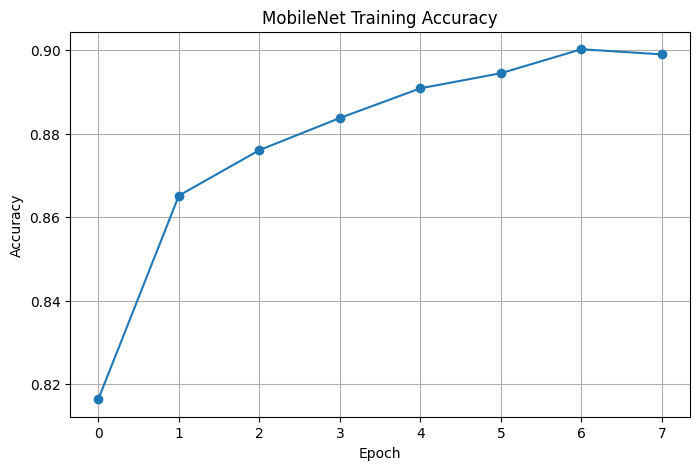

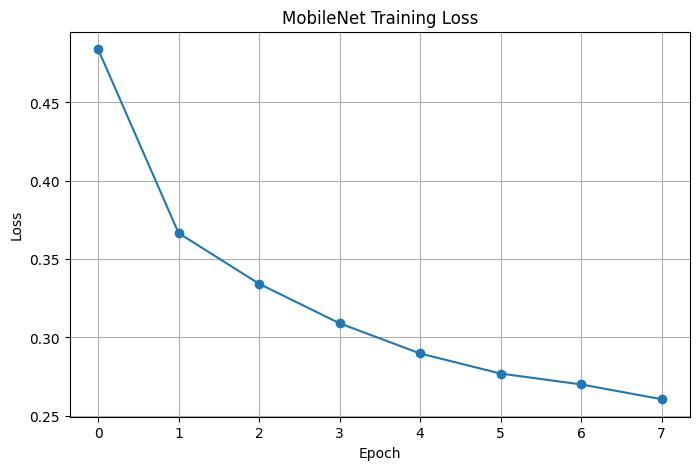

In [60]:


# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], marker='o')
plt.title('MobileNet Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], marker='o')
plt.title('MobileNet Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## MobileNet Training (Behavior) :

The training accuracy increased steadily from approximately 81.7% in the first epoch to 89.9% in the final epoch.

Simultaneously, the training loss decreased from approximately 0.48 to 0.26.

The smooth increase in accuracy and decrease in loss indicate stable convergence of the optimization process. No evidence of unstable training behavior was observed during the training phase.

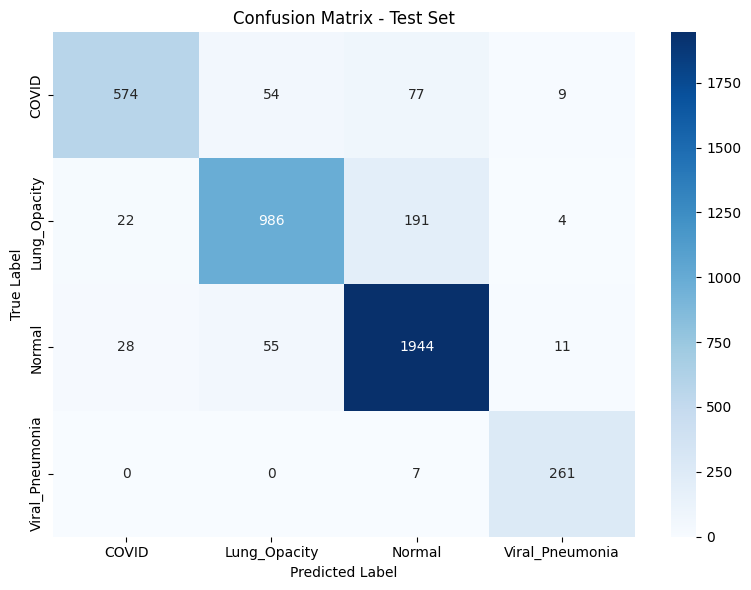

In [61]:
cm = confusion_matrix(y_true, y_pred)

class_names = [
    "COVID",
    "Lung_Opacity",
    "Normal",
    "Viral_Pneumonia"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()

## Confusion Matrix Analysis

The confusion matrix demonstrates strong classification performance across all four categories.

Most predictions are concentrated along the diagonal, indicating that the majority of samples were correctly classified.

The largest source of error was the confusion between Lung Opacity and Normal cases, where 191 Lung Opacity images were classified as Normal. A similar pattern was observed for COVID cases, with 77 COVID images classified as Normal.

Confusion between COVID and Lung Opacity was also observed, which is expected due to overlapping radiographic manifestations in chest X-ray images.

Viral Pneumonia achieved the strongest performance, with only 7 misclassified samples out of 268 test images.

Overall, the confusion matrix confirms that the MobileNet model provides robust performance while highlighting the inherent difficulty of distinguishing between certain pulmonary(lung) pathologies.

In [65]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    probs = final_model.predict(images, verbose=0)

    y_prob.extend(probs)

    y_pred.extend(np.argmax(probs, axis=1))

    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

y_true shape: (4223,)
y_pred shape: (4223,)
y_prob shape: (4223, 4)


In [66]:
print(y_prob[:5])

[[3.85620719e-04 2.09847582e-03 9.97515917e-01 1.43466465e-08]
 [4.13335101e-06 1.41336044e-04 9.99601662e-01 2.52900034e-04]
 [3.66090275e-02 1.03930220e-01 8.27139795e-01 3.23209353e-02]
 [2.47303210e-02 9.19101480e-03 9.63654339e-01 2.42437259e-03]
 [7.35628535e-04 6.49314316e-04 9.98615026e-01 1.93369729e-08]]


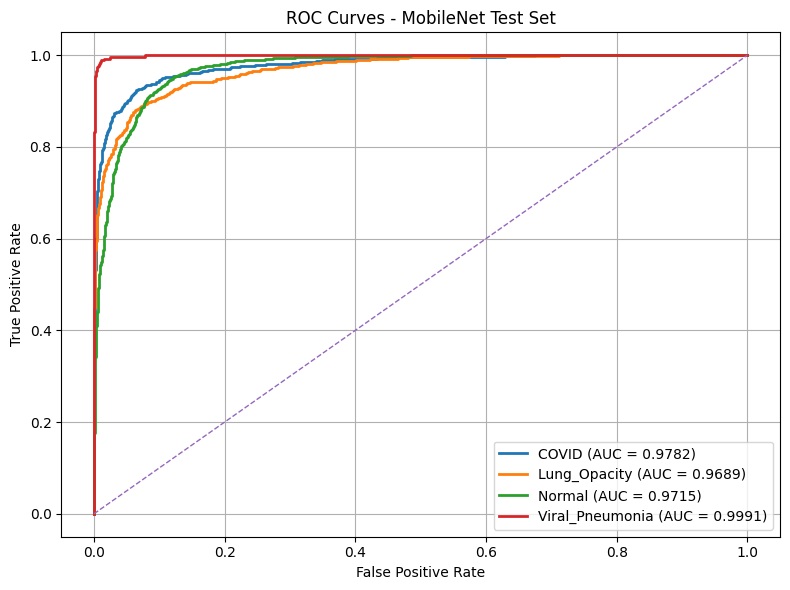


AUC Scores
COVID: 0.9782
Lung_Opacity: 0.9689
Normal: 0.9715
Viral_Pneumonia: 0.9991

Macro AUC: 0.9794531538435717


In [67]:
# Class names
class_names = [
    "COVID",
    "Lung_Opacity",
    "Normal",
    "Viral_Pneumonia"
]

# Convert labels to one-hot format
y_true_bin = label_binarize(y_true, classes=[0,1,2,3])

# ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# Plot
plt.figure(figsize=(8,6))

for i in range(4):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - MobileNet Test Set")

plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

# Print AUC scores
print("\nAUC Scores")
for i in range(4):
    print(f"{class_names[i]}: {roc_auc[i]:.4f}")

print("\nMacro AUC:",
      np.mean(list(roc_auc.values())))

## 💁 ROC/AUC Analyzsis:
  The ROC analysis demonstrated strong discriminative performance of the MobileNet model across all four chest X-ray classes. The obtained AUC values were 0.9782 for COVID, 0.9689 for Lung Opacity, 0.9715 for Normal, and 0.9991 for Viral Pneumonia, resulting in a macro-average AUC of 0.9795. These results indicate that the model achieved excellent class separability and maintained high diagnostic performance independently of a specific decision threshold. The highest performance was observed for Viral Pneumonia, while Lung Opacity represented the most challenging category due to radiographic similarities with both COVID and Normal cases. Overall, the ROC analysis confirms the robustness and reliability of the proposed MobileNet-based classification framework.


## Final Evaluation

The proposed MobileNet model achieved strong performance in the classification of chest X-ray images into four categories: COVID-19, Lung Opacity, Normal, and Viral Pneumonia. Using stratified 5-fold cross-validation, the model obtained a mean accuracy of 87.96%, significantly outperforming the baseline CNN (67.65%). When evaluated on the independent test set, MobileNet achieved an accuracy of 89.15% with a macro AUC of 0.9795. The confusion matrix and ROC analysis demonstrated robust classification performance across all classes, with the highest performance observed for Viral Pneumonia and the main classification challenges occurring between COVID-19, Lung Opacity, and Normal cases. Overall, the results indicate that MobileNet is an effective and reliable approach for automated chest X-ray disease classification.
